In [ ]:
import numpy as np
import random
from PIL import Image
from matplotlib import pyplot as plt

In [ ]:
def array_to_img(array):
    a = np.array([255 if x <= 0 else 0 for x in array]).reshape(-1, 3)
    img = Image.fromarray(np.uint8(a)).convert('1')
    plt.imshow(img)
    plt.show()
    return img

In [ ]:
class BAM:
  def __init__(self):
    self.__weights = None
    self.patterns = None
    self.associations = None

  def __call__(self, patterns, associations):
    self.patterns = np.array(patterns)
    self.associations = np.array(associations)
    self.__weights = np.dot(np.transpose(self.associations), self.patterns) # Запоминание образцов

  # Функция для ассоциативного восстановления образа
  def recall(self, distorted_pattern=None, association=None):
    rold = distorted_pattern if distorted_pattern is not None else association
    recalled = rold[0] - 1
    while not (np.array_equal(rold, recalled)):
        rold = recalled
        if distorted_pattern is not None and np.array(distorted_pattern).shape == self.patterns[0].shape:
            recalled = np.dot(self.__weights, distorted_pattern)
        if association is not None and np.array(association).shape == self.associations[0].shape:
            recalled = np.dot(np.transpose(self.__weights), association)
    return np.sign(recalled)

In [ ]:
def PixelArray(img): #переход от цветного трехмерного массива к ч/б двумерному
    img = np.array(img)
    oz = np.zeros((5, 3))
    for i in range(img.shape[0]):
      oz[i] = [x[0] for x in img[i]]
    oz[oz == 0] = 1
    oz[oz > 1] = -1 # 255 - это белый, белый пусть будет -1
    return oz

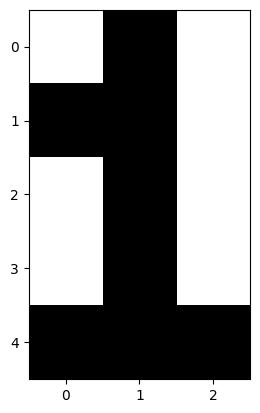

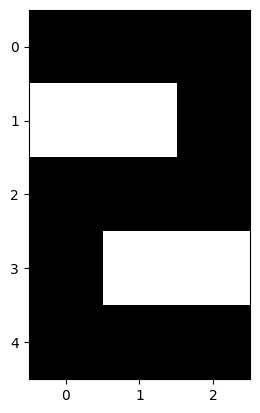

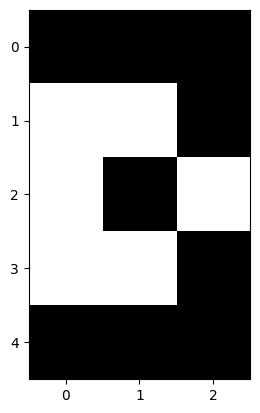

In [ ]:
numbers = []
for i in range(1, 4):
  digit = Image.open(f'digits/{i}.png')
  plt.imshow(digit)
  plt.show()
  numbers.append(PixelArray(digit).flatten())
numbers = np.array(numbers)

In [ ]:
associations = [[-1, -1, 1], [-1, 1, -1], [-1, 1, 1]]
print(np.dot(np.transpose(associations), numbers))

[[-1. -3. -1.  1.  1. -1.  1. -3.  1.  1.  1.  1. -3. -3. -3.]
 [ 3.  1.  3. -3. -3.  3.  1.  1.  1.  1. -3.  1.  1.  1.  1.]
 [-1.  1. -1.  1.  1. -1. -3.  1. -3. -3.  1.  1.  1.  1.  1.]]


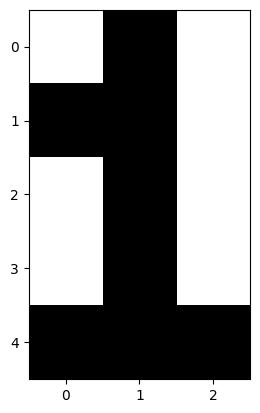

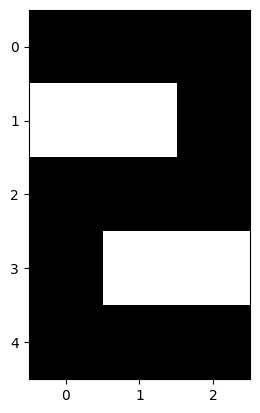

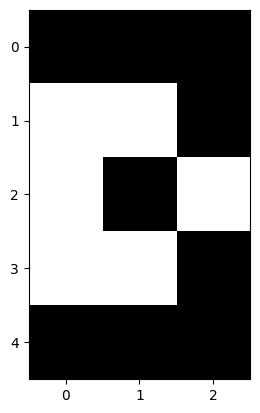

In [ ]:
array_to_img(numbers[0])
array_to_img(numbers[1])
array_to_img(numbers[2])

In [ ]:
network = BAM()
network(numbers, associations)

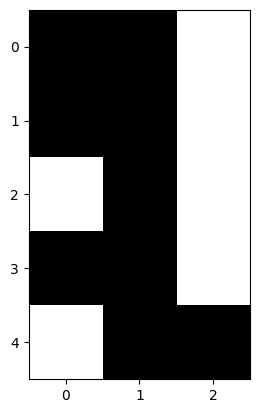

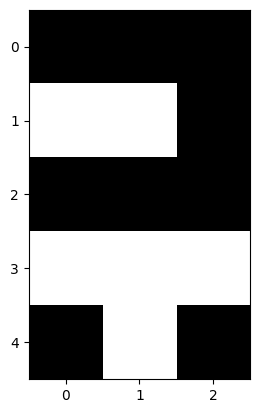

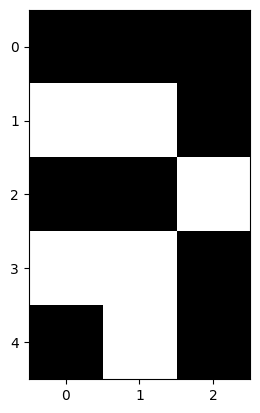

In [ ]:
distorted_numbers = []
for i in range(1, 4):
  digit = Image.open(f'digits/d{i}.png')
  plt.imshow(digit)
  plt.show()
  distorted_numbers.append(PixelArray(digit).flatten())
distorted_numbers = np.array(distorted_numbers)

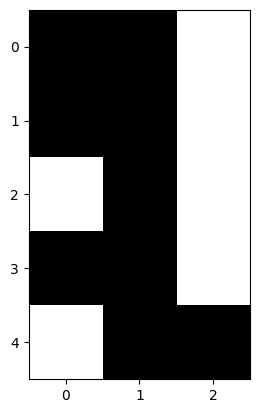

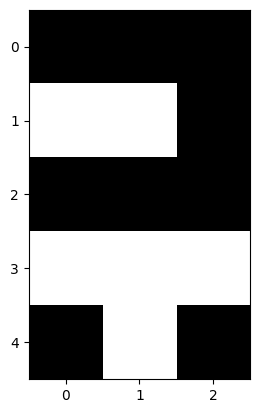

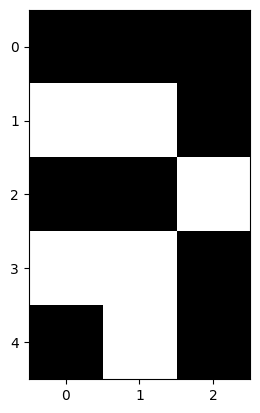

In [ ]:
array_to_img(distorted_numbers[0])
array_to_img(distorted_numbers[1])
array_to_img(distorted_numbers[2])

In [ ]:
# Восстановление ассоциированных образов
answer = lambda a: 1 if np.array_equal(associations[0], a) is True else (2 if np.array_equal(associations[1], a) is True else 3)
for distorted_pattern in distorted_numbers:
    restored_association = network.recall(distorted_pattern)
    print("Искаженный образ:", distorted_pattern)
    print("\tЦифра:", answer(restored_association))
    print("\tВосстановленная ассоциация:", restored_association)

Искаженный образ: [ 1.  1. -1.  1.  1. -1. -1.  1. -1.  1.  1. -1. -1.  1.  1.]
	Цифра: 1
	Восстановленная ассоциация: [-1. -1.  1.]
Искаженный образ: [ 1.  1.  1. -1. -1.  1.  1.  1.  1. -1. -1. -1.  1. -1.  1.]
	Цифра: 2
	Восстановленная ассоциация: [-1.  1. -1.]
Искаженный образ: [ 1.  1.  1. -1. -1.  1.  1.  1. -1. -1. -1.  1.  1. -1.  1.]
	Цифра: 3
	Восстановленная ассоциация: [-1.  1.  1.]


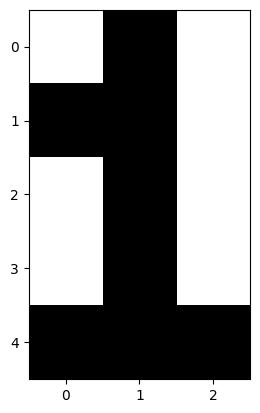

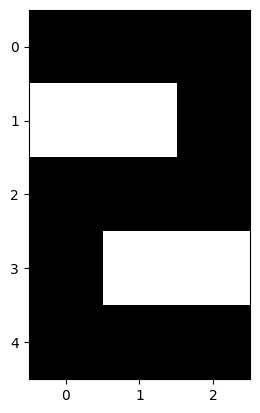

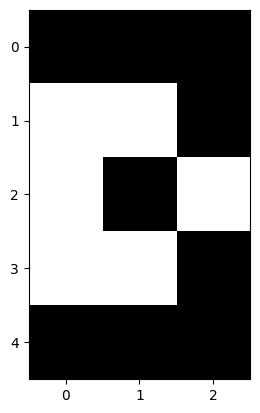

In [ ]:
for association in associations:
    array_to_img(network.recall(association=association))

Не заложенная ассоциация

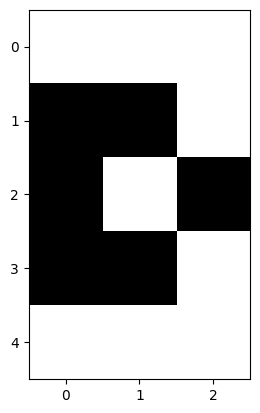

In [ ]:
array_to_img(network.recall(association=[1, -1,  -1]))